In [ ]:
# ==========================================
# Standard Solution: Matrix–Vector Operations
# ==========================================

import torch

# ----- Given -----
A = torch.tensor([[2., -1., 0.],
                  [1.,  3., 2.],
                  [0., -2., 1.]])
x = torch.tensor([[1.],
                  [2.],
                  [3.]])

# ----- 1) Compute y = A x -----
y = A @ x
print("A =\n", A)
print("x =\n", x)
print("y = A @ x =\n", y)
print("y shape:", y.shape)

# ----- 2) Compute z = A^T y -----
z = A.T @ y
print("\nA^T =\n", A.T)
print("z = A^T @ y =\n", z)

# ----- 3) Compute norms and dot product -----
frobenius_norm = torch.norm(A,p="fro")          # ||A||_F
x_norm = torch.norm(x,p=2)                  # ||x||_2
dot_xy = torch.dot(x.squeeze(), y.squeeze())  # x^T y

print("\nFrobenius norm of A:", frobenius_norm.item())
print("2-norm of x:", x_norm.item())
print("Dot product x^T y:", dot_xy.item())


A =
 tensor([[ 2., -1.,  0.],
        [ 1.,  3.,  2.],
        [ 0., -2.,  1.]])
x =
 tensor([[1.],
        [2.],
        [3.]])
y = A @ x =
 tensor([[ 0.],
        [13.],
        [-1.]])
y shape: torch.Size([3, 1])

A^T =
 tensor([[ 2.,  1.,  0.],
        [-1.,  3., -2.],
        [ 0.,  2.,  1.]])
z = A^T @ y =
 tensor([[13.],
        [41.],
        [25.]])

Frobenius norm of A: 4.898979663848877
2-norm of x: 3.7416574954986572
Dot product x^T y: 23.0


MSE (random weights): 0.373741


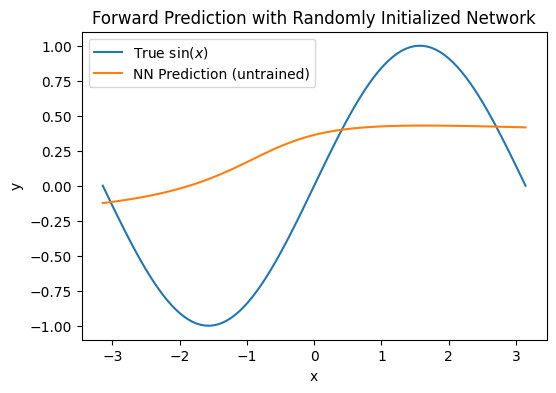

In [ ]:
# =============================================
# Standard Solution: PyTorch Feedforward Network
# =============================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Data: y = sin(x)
torch.manual_seed(0)
x = torch.linspace(-torch.pi, torch.pi, 100).unsqueeze(1)
y = torch.sin(x)

# 2. Define model: 1 -> 16 -> 16 -> 1
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.Tanh(),
    nn.Linear(16, 16),
    nn.Tanh(),
    nn.Linear(16, 1)
)

# 3. Forward-only prediction (no training)
model.eval()
with torch.no_grad():
    y_pred = model(x)

# 4. Compute MSE loss
mse = torch.mean((y_pred - y) ** 2)
print(f"MSE (random weights): {mse.item():.6f}")

# 5. Visualization
plt.figure(figsize=(6,4))
plt.plot(x.numpy(), y.numpy(), label='True $\\sin(x)$')
plt.plot(x.numpy(), y_pred.numpy(), label='NN Prediction (untrained)')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Forward Prediction with Randomly Initialized Network')
plt.show()


In [ ]:
# ============================================================
# Practice: Exploring CNN Layers in PyTorch (Grayscale Version)
# ============================================================

import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load and preprocess a grayscale image (400x400)
# ------------------------------------------------------------
img = Image.open("example.png").convert("L")  # convert to grayscale ('L' mode)
transform = T.Compose([
    T.Resize((400, 400)),
    T.ToTensor()           # shape: (1, H, W)
])
x = transform(img).unsqueeze(0)  # add batch dimension -> (1, 1, 400, 400)

print("Input shape:", x.shape)   # should be (1, 1, 400, 400)

# 2. Define convolution layers
# ------------------------------------------------------------
conv1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=0)
conv2 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, stride=1, padding=1)
conv3 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=5, stride=2, padding=2)

# 3. Forward pass through each convolution layer
# ------------------------------------------------------------
with torch.no_grad():
    y1 = conv1(x)
    y2 = conv2(x)
    y3 = conv3(x)

print("\nOutput shapes:")
print(f"Conv1 (K=3,S=1,P=0): {y1.shape}")
print(f"Conv2 (K=3,S=1,P=1): {y2.shape}")
print(f"Conv3 (K=5,S=2,P=2): {y3.shape}")

# 4. Visualize the feature maps (grayscale)
# ------------------------------------------------------------
def show_gray(tensor, title):
    img_array = tensor[0, 0].detach().cpu().numpy()
    plt.imshow(img_array, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

show_gray(x, "Original Grayscale Image")
show_gray(y1, "After Conv1 (K=3, S=1, P=0)")
show_gray(y2, "After Conv2 (K=3, S=1, P=1)")
show_gray(y3, "After Conv3 (K=5, S=2, P=2)")


FileNotFoundError: [Errno 2] No such file or directory: 'example.png'